# Proyek Analisis Data: [Input Nama Dataset]
- **Nama:** Atiam Tio Wandi
- **Email:** atiamtio@gmail.com
- **ID Dicoding:** ds001b6y0279

## Menentukan Pertanyaan Bisnis

**SMART Question** adalah sebuah framework untuk merumuskan pertanyaan secara terstruktur agar memeperoleh informasi yang mendalam.

* **Spesific (Spesifik)**
  * Pertanyaan harus jelas, fokus pada sebuah topik tertentu, dan tidak bermakna ganda. Hindari pertanyaan yang terlalu luas.
    * Salah: Bagaimana cara meningkatkan penjualan?
    * Benar: Faktor apa saja yang memengaruhi penurunan penjualan produk kategori elektronik di wilayah Jakarta selama kuartal terakhir?
* **Measurable (Terukur)**
  * Pertanyaan harus bisa dijawab dengan angka atau matrix yang konkret, harus tahu apa yang akan dihitung.
    * Salah: Apakah pelanggan senang dengan layanan kita?
    * Benar: Berapa skor rata-rata Customer Satisfaction untuk layanan purna jual bulan ini dibandingkan bulan lalu?
* **Action-Oriented (Berorientasi Aksi)**
  * Hasil dari pertanyaan harus bisa memberikan arahan untuk melakukan tindakan nyata. Jika pertanyaan terjawab, stakeholder harus tahu apa langkah selanjutnya.
    * Salah: Mengapa orang suka berbelanja?
    * Benar: Fitur apa pada aplikasi yang paling sering digunakan sebelum pengguna memutuskan untuk melakukan checkout?
* **Relevant (Relevan)**
  * Hasil dari pertanyaan harus sejalan dengan tujuan utama bisnis atau masalah yang sedang dihadapi.
    * Salah: Menanyakan tentang stok gudang saat masalah utamanya adalah efektivitas kampanye media sosial.
    * Benar: Apakah kampanye iklan di Instagram memberikan Return on Ad Spend (ROAS) yang lebih tinggi dibandingkan iklan di TikTok?
* **Time-bound (Terikat Waktu)**
  * Pertanyaan harus ada batasan waktu yang jelas agar analisis memiliki konteks yang tepat.
    * Salah: Berapa banyak pengguna baru kita?
    * Benar: Berapa tingkat pertumbuhan pengguna baru secara bulanan (Month-over-Month) sepanjang tahun 2025?

**Contoh pertanyaan bisnis yang memenuhi seluruh elemen SMART**

***"Faktor apa saja yang memengaruhi penurunan conversion rate pada pengguna aplikasi Android di wilayah Jabodetabek sebesar 5% selama periode Flash Sale Maret 2026?"***

Keterangan:

- **Specific**: Fokus pada "penurunan conversion rate" untuk "aplikasi Android" di "Jabodetabek". Bukan sekadar penjualan turun.
- **Measurable**: Ada angka konkret yang ingin dianalisis, yaitu penurunan sebesar "5%".
- **Action-Oriented**: Dengan mengetahui faktor penyebabnya misalnya bug pada versi Android tertentu atau kendala logistik di Jabodetabek, tim bisa langsung melakukan perbaikan teknis atau operasional.
- **Relevant**: Penurunan konversi saat Flash Sale adalah masalah kritis bagi bisnis retail/e-commerce.
- **Time-bound**: Dibatasi pada periode spesifik "Flash Sale Maret 2026".

- **Pertanyaan 1:** Seberapa besar pengaruh keterlambatan pengiriman terhadap review_score pelanggan pada pesanan yang berstatus 'delivered' selama periode 2017–2018?

Keterangan:
1. Specific: fokus pada satu hubungan jelas: keterlambatan pengiriman vs skor ulasan, bukan "menganalisis kepuasan pelanggan" secara umum
2. Measurable: terukur lewat variabel numerik: selisih hari keterlambatan dan review_score 1–5
3. Action-oriented: hasilnya bisa langsung diarahkan ke rekomendasi: kategori/seller mana yang perlu perbaikan SLA pengiriman
4. Relevant: menghubungkan 3 tabel inti (orders, order_reviews, products) yang memang tersedia dan saling terkait via order_id/product_id
5. Time-bound: dibatasi pada rentang waktu data yang tersedia (2017–2018)

- **Pertanyaan 2:** Kategori produk mana yang memiliki kontribusi pendapatan tertinggi namun juga tingkat review_score rendah (≤2), sehingga perlu evaluasi kualitas produk selama 2017–2018

Keterangan:
1. Specific: Pertanyaan ini spesifik menargetkan irisan dua kondisi sekaligus: kategori dengan pendapatan tinggi DAN skor ulasan rendah (≤2).
2. Measurable: Semua variabel bisa dihitung langsung dari data pendapatan per kategori, lalu dibandingkan dengan rata-rata/proporsi review_score ≤2. Hasil akhirnya berupa angka/ranking yang bisa dibandingkan antar kategori.
3. Action-oriented:	Temuan bisa langsung diterjemahkan jadi rekomendasi bisnis konkret. misalnya kategori produk mana yang perlu audit kualitas, quality control, atau evaluasi seller.
4. Relevant	Menghubungkan tiga tabel yang memang tersedia dan berelasi jelas (products_dataset, order_items_dataset, order_reviews_dataset) sehingga pertanyaan ini benar-benar bisa dijawab dengan data yang ada.
5. Time-bound:	Dibatasi pada rentang data yang tersedia yaitu 2017–2018

## Import Semua Packages/Library yang Digunakan

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown

## Data Wrangling

### Gathering Data

In [2]:
customers_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\customers_dataset.csv')
customers_df.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
geolocation_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\geolocation_dataset.csv')
geolocation_df.head()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP


In [4]:
order_item_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\order_items_dataset.csv')
order_item_df.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [5]:
order_payments_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\order_payments_dataset.csv')
order_payments_df.head()

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45


In [6]:
order_reviews_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\order_reviews_dataset.csv')
order_reviews_df.head()

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53


In [7]:
orders_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\orders_dataset.csv')
orders_df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
product_category_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\product_category_name_translation.csv')
product_category_df.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [9]:
products_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\products_dataset.csv')
products_df.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [10]:
sellers_df = pd.read_csv(r'C:\Tio\ASAH\Proyek Fundamental Analisis Data\E-commerce-public-dataset\E-Commerce Public Dataset\sellers_dataset.csv')
sellers_df.head()

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP


**Insight:** (Opsional)

Dari total data yang dimuat, terdapat 9 tabel yang memuat infromasi berbeda. Sembilan tabel tersebut memiliki kolom kunci yaitu `order_id`, `customer_id`, `product_id`, dan `seller_id`. Untuk menjawab pertanyaan sebelumnya, tabel `order_dataset` dan `order_reviews_dataset` mejadi tabel utama untuk dianalisis. Lalu tabel lainnya yang dibutuhkan adalah  `orders_df`, `order_item_df`, `order_reviews_df`, `products_df`, dan `product_category_df`. Sehingga proses selanjutnya hanya akan berfokus pada tabel ini

### Assessing Data

#### Identifying missing value problem

In [11]:
print('Missing value pada tabel orders_df')
print(orders_df.isna().sum())
print('Missing value pada tabel order_items_df')
print(order_item_df.isna().sum())
print('Missing value pada tabel order_review_df')
print(order_reviews_df.isna().sum())
print('Missing value pada tabel products_df')
print(products_df.isna().sum())
print('Missing value pada tabel category_translation')
print(product_category_df.isna().sum())

Missing value pada tabel orders_df
order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64
Missing value pada tabel order_items_df
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64
Missing value pada tabel order_review_df
review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64
Missing value pada tabel products_df
product_id                      0
product_category_name         610
product_name_lenght           

**Step to take:**
- Analisis penyebab hilangnya data pada tabel o`rder_df` dan `products_df` lalu tangani sesuai kasusnya masing-masing
- Missing value pada tabel `order_review_df` terjadi karena setiap pelanggan tidak diwajibkan untuk memberikan ulasan, karena kolom yang memiliki missing value pada tabel ini tidak diunakan, maka nilai kosongnya didiamkan saja

**Insight(opsional):**
- Hanya 610 dari 32.951 produk (±1,85%) yang kehilangan informasi kategori dampaknya kecil terhadap analisis agregat per kategori

#### Identifying Duplicated Data Problem

In [12]:
print("Baris duplikat penuh pada order_reviews_df:", order_reviews_df.duplicated().sum())
print("Baris duplikat penuh pada orders_df:", orders_df.duplicated().sum())
print("Baris duplikat penuh pada order_items_df:", order_item_df.duplicated().sum())
print("Baris duplikat penuh pada products_df:", products_df.duplicated().sum())
print("Baris duplikat penuh pada products_df:", product_category_df.duplicated().sum())

Baris duplikat penuh pada order_reviews_df: 0
Baris duplikat penuh pada orders_df: 0
Baris duplikat penuh pada order_items_df: 0
Baris duplikat penuh pada products_df: 0
Baris duplikat penuh pada products_df: 0


**Step to take:**
- Data tidak ada terduplikat, sehingga penanganan duplicate data tidak perlu dilakukan

**Insight(opsional):**
- Dataset yang digunakan tidak memiliki duplikasi data. Ada kemungkinan duplikasi pada `order_id` dalam tabel `order_review`, namun diasumsikan pemesan memberikan ulasan lebih dari satu kali pada pesanan yang sama

#### Identifying Inconsistent/Invalid Value Problem

In [13]:
display(Markdown("**Deskripsi Tabel Orders:**"))
display(orders_df.describe(include='all'))

display(Markdown("**Deskripsi Tabel Order Items:**"))
display(order_item_df.describe())

display(Markdown("**Deskripsi Tabel Order Reviews:**"))
display(order_reviews_df.describe())

display(Markdown("**Deskripsi Tabel Products:**"))
display(products_df.describe())

display(Markdown("**Deskripsi Tabel Product Category Translation:**"))
display(product_category_df.describe())

**Deskripsi Tabel Orders:**

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


**Deskripsi Tabel Order Items:**

,order_item_id,price,freight_value
count,112650.000000,112650.000000,112650.000000
mean,1.197834,120.653739,19.990320
std,0.705124,183.633928,15.806405
min,1.000000,0.850000,0.000000
25%,1.000000,39.900000,13.080000
50%,1.000000,74.990000,16.260000
75%,1.000000,134.900000,21.150000
max,21.000000,6735.000000,409.680000


**Deskripsi Tabel Order Reviews:**

,review_score
count,99224.000000
mean,4.086421
std,1.347579
min,1.000000
25%,4.000000
50%,5.000000
75%,5.000000
max,5.000000


**Deskripsi Tabel Products:**

,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
count,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000
mean,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728
std,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047
min,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000
25%,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000
50%,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000
75%,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000
max,76.000000,3992.000000,20.000000,40425.000000,105.000000,105.000000,118.000000


**Deskripsi Tabel Product Category Translation:**

,product_category_name,product_category_name_english
count,71,71
unique,71,71
top,beleza_saude,health_beauty
freq,1,1


**Steps to take:**
- tidak perlu ditangani karena tidak ada invalid value

**Insight:**
- Dataset yang digunakan tidak memiliki invalid value, sehingga bisa langsung dilanjutkan ke tahap selanjutnya

#### Identifying Incorrect Data Type Problem

In [14]:
print('Tipe Data orders_df')
print(orders_df.dtypes)
print('Tipe data order_items_df')
print(order_item_df.dtypes)
print('tipe data prder_reviews_df')
print(order_reviews_df.dtypes)
print('Tipe data products_df')
print(products_df.dtypes)
print('Tipe data product_category_df')
print(product_category_df.dtypes)

Tipe Data orders_df
order_id                         str
customer_id                      str
order_status                     str
order_purchase_timestamp         str
order_approved_at                str
order_delivered_carrier_date     str
order_delivered_customer_date    str
order_estimated_delivery_date    str
dtype: object
Tipe data order_items_df
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object
tipe data prder_reviews_df
review_id                    str
order_id                     str
review_score               int64
review_comment_title         str
review_comment_message       str
review_creation_date         str
review_answer_timestamp      str
dtype: object
Tipe data products_df
product_id                        str
product_category_name             str
product_name_lenght           float64
produc

**Steps to Take:**
- Seluruh kolom tanggal pada `orders_df` masih bertipe `object` (string), bukan `datetime` perlu dikonversi dengan `pd.to_datetime()` agar dapat dilakukan operasi pengurangan tanggal (menghitung selisih hari keterlambatan) pada tahap EDA

**Insight:**
- Tanpa konversi tipe data, perhitungan selisih waktu pengiriman (hari terlambat/lebih cepat) tidak dapat dilakukan secara numerik

### Cleaning Data

#### Fixing Missing Value Problem

In [15]:
nan_rows_all = orders_df[orders_df.isna().any(axis=1)]

display(nan_rows_all)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaN,NaN,2017-05-09 00:00:00
44,ee64d42b8cf066f35eac1cf57de1aa85,caded193e8e47b8362864762a83db3c5,shipped,2018-06-04 16:44:48,2018-06-05 04:31:18,2018-06-05 14:32:00,NaN,2018-06-28 00:00:00
103,0760a852e4e9d89eb77bf631eaaf1c84,d2a79636084590b7465af8ab374a8cf5,invoiced,2018-08-03 17:44:42,2018-08-07 06:15:14,NaN,NaN,2018-08-21 00:00:00
128,15bed8e2fec7fdbadb186b57c46c92f2,f3f0e613e0bdb9c7cee75504f0f90679,processing,2017-09-03 14:22:03,2017-09-03 14:30:09,NaN,NaN,2017-10-03 00:00:00
154,6942b8da583c2f9957e990d028607019,52006a9383bf149a4fb24226b173106f,shipped,2018-01-10 11:33:07,2018-01-11 02:32:30,2018-01-11 19:39:23,NaN,2018-02-07 00:00:00
...,...,...,...,...,...,...,...,...
99283,3a3cddda5a7c27851bd96c3313412840,0b0d6095c5555fe083844281f6b093bb,canceled,2018-08-31 16:13:44,NaN,NaN,NaN,2018-10-01 00:00:00
99313,e9e64a17afa9653aacf2616d94c005b8,b4cd0522e632e481f8eaf766a2646e86,processing,2018-01-05 23:07:24,2018-01-09 07:18:05,NaN,NaN,2018-02-06 00:00:00
99347,a89abace0dcc01eeb267a9660b5ac126,2f0524a7b1b3845a1a57fcf3910c4333,canceled,2018-09-06 18:45:47,NaN,NaN,NaN,2018-09-27 00:00:00
99348,a69ba794cc7deb415c3e15a0a3877e69,726f0894b5becdf952ea537d5266e543,unavailable,2017-08-23 16:28:04,2017-08-28 15:44:47,NaN,NaN,2017-09-15 00:00:00


In [16]:
order_status_cat = orders_df['order_status'].unique()

print(order_status_cat)

<ArrowStringArray>
[  'delivered',    'invoiced',     'shipped',  'processing', 'unavailable',
    'canceled',     'created',    'approved']
Length: 8, dtype: str


In [17]:
for status in order_status_cat:
   
    filtered_df = orders_df[orders_df['order_status'] == status]
    
    missing_count = filtered_df.isna().sum()
    
    print(f'Jumlah data hilang pada order status {status} = {missing_count}')

Jumlah data hilang pada order status delivered = order_id                          0
customer_id                       0
order_status                      0
order_purchase_timestamp          0
order_approved_at                14
order_delivered_carrier_date      2
order_delivered_customer_date     8
order_estimated_delivery_date     0
dtype: int64
Jumlah data hilang pada order status invoiced = order_id                           0
customer_id                        0
order_status                       0
order_purchase_timestamp           0
order_approved_at                  0
order_delivered_carrier_date     314
order_delivered_customer_date    314
order_estimated_delivery_date      0
dtype: int64
Jumlah data hilang pada order status shipped = order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                   0
order_delivered_carrier_date        0
order_delivered_cu

**Keterangan:**
erdasarkan hasil analisis tersebut, diketahui nilai yang hilang bergantung pada status order. Pada dasarnya, pesanan yang belm memiliki status "Delivered" akan memiliki nilai kosong karena belum ada data untuk mengisi nilai tersebut. Selain itu, karena kita hanya fokus ke pesanan yang berstatus "Delivered", sehingga kita hanya perlu menangani mising value pada pesanan yang berstatus "Delivered"

In [18]:
date_cols = ['order_purchase_timestamp', 'order_approved_at',
             'order_delivered_carrier_date', 'order_delivered_customer_date',
             'order_estimated_delivery_date']
for col in date_cols:
    orders_df[col] = pd.to_datetime(orders_df[col], errors='coerce')

avg_to_approved = (orders_df['order_approved_at'] - orders_df['order_purchase_timestamp']).mean()
avg_to_carrier = (orders_df['order_delivered_carrier_date'] - orders_df['order_approved_at']).mean()
avg_to_customer = (orders_df['order_delivered_customer_date'] - orders_df['order_delivered_carrier_date']).mean()

orders_df['order_approved_at'] = orders_df['order_approved_at'].fillna(
    orders_df['order_purchase_timestamp'] + avg_to_approved
)

orders_df['order_delivered_carrier_date'] = orders_df['order_delivered_carrier_date'].fillna(
    orders_df['order_approved_at'] + avg_to_carrier
)

orders_df['order_delivered_customer_date'] = orders_df['order_delivered_customer_date'].fillna(
    orders_df['order_delivered_carrier_date'] + avg_to_customer
)

row_delivered = orders_df[orders_df['order_status'] == 'delivered']
display(row_delivered.isna().sum())


order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
dtype: int64

**Keterangan:**
Missing value pada kolom `order_approved_at`, `order_delivered_carrier_date`, dan  `order_delivered_customer_date` diisi dengan rata rata selisih waktu antar poin.

In [19]:
nan_rows_products = products_df[products_df.isna().any(axis=1)]

display(nan_rows_products)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
105,a41e356c76fab66334f36de622ecbd3a,NaN,NaN,NaN,NaN,650.0,17.0,14.0,12.0
128,d8dee61c2034d6d075997acef1870e9b,NaN,NaN,NaN,NaN,300.0,16.0,7.0,20.0
145,56139431d72cd51f19eb9f7dae4d1617,NaN,NaN,NaN,NaN,200.0,20.0,20.0,20.0
154,46b48281eb6d663ced748f324108c733,NaN,NaN,NaN,NaN,18500.0,41.0,30.0,41.0
197,5fb61f482620cb672f5e586bb132eae9,NaN,NaN,NaN,NaN,300.0,35.0,7.0,12.0
...,...,...,...,...,...,...,...,...,...
32515,b0a0c5dd78e644373b199380612c350a,NaN,NaN,NaN,NaN,1800.0,30.0,20.0,70.0
32589,10dbe0fbaa2c505123c17fdc34a63c56,NaN,NaN,NaN,NaN,800.0,30.0,10.0,23.0
32616,bd2ada37b58ae94cc838b9c0569fecd8,NaN,NaN,NaN,NaN,200.0,21.0,8.0,16.0
32772,fa51e914046aab32764c41356b9d4ea4,NaN,NaN,NaN,NaN,1300.0,45.0,16.0,45.0


In [20]:
products_df['product_category_name'] = products_df['product_category_name'].fillna('other')

products_df.isna().sum()

product_id                      0
product_category_name           0
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

**Keterangan:**
Missing value pada kolom product_category_name diising dengan "other". lalu kolom lainnya yang memiliki missing value diabaikan karena tidak digunakan untuk analisis

**Insight:**
Pesanan dengan status "delivered" pada tabel `orders_df` kini tidak memiliki missing value, karena sudah diisi dengan nilai rata rata selisih waktu. Product_category_name yang missing telah diganti dengan "other" atau lainnya.

#### Fixing Duplicate Data Problem

**Insight:**
Karena pada taap sebelumnya tidak ditemukan data yag duplikat, jadi tidak perlu ada penanganan data duplikat pada case ini

#### Fixing Invalid Value Problem

**Insight:**
Pada tahap sebelumnya, dataset yang digunakan tidak memiliki invalid value sehingga tidak dibutuhkan penanganan untuk invalid value

#### Fixing Incorrect Data Type Problem

In [21]:
orders_df['order_purchase_timestamp'] = pd.to_datetime(orders_df['order_purchase_timestamp'])
orders_df['order_approved_at'] = pd.to_datetime(orders_df['order_approved_at'])
orders_df['order_delivered_carrier_date'] = pd.to_datetime(orders_df['order_delivered_carrier_date'])
orders_df['order_delivered_customer_date'] = pd.to_datetime(orders_df['order_delivered_customer_date'])
orders_df['order_estimated_delivery_date'] = pd.to_datetime(orders_df['order_estimated_delivery_date'])

print(orders_df.dtypes)

order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object


**Insight:**
Seluruh kolom tanggal kini bertipe `datetime64`, siap digunakan untuk perhitungan selisih waktu pengiriman

## Exploratory Data Analysis (EDA)

### Pertanyaan 1: Seberapa besar pengaruh keterlambatan pengiriman terhadap review_score pelanggan pada pesanan yang berstatus 'delivered' selama periode 2017–2018.

In [47]:
delivered_df = orders_df[orders_df['order_status']=='delivered']
delivered_df = orders_df[
    (orders_df['order_status'] == 'delivered') & 
    (orders_df['order_purchase_timestamp'] >= '2017-01-01') & 
    (orders_df['order_purchase_timestamp'] < '2018-01-01')
].copy()

delivered_df['delay_time'] = (delivered_df['order_delivered_customer_date'] - delivered_df['order_estimated_delivery_date']).dt.days
delivered_df['status_pengiriman'] = np.where(delivered_df['delay_time'] > 0, 'Terlambat', 'Tepat waktu')

q1_df = delivered_df.merge(order_reviews_df[['order_id', 'review_score']], on='order_id', how='inner')
q1_df = q1_df.merge(order_item_df[['order_id', 'product_id']], on='order_id', how='inner')
q1_df = q1_df.merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')

print("Jumlah pesanan delivered yang dianalisis:", q1_df['order_id'].nunique())
print()
print("Rata-rata review_score berdasarkan status pengiriman:")
display(q1_df.groupby('status_pengiriman')['review_score'].agg(['mean', 'count']))
print()
print("Korelasi delay_days terhadap review_score:", round(q1_df['delay_time'].corr(q1_df['review_score']), 4))

Jumlah pesanan delivered yang dianalisis: 43100

Rata-rata review_score berdasarkan status pengiriman:


,mean,count
status_pengiriman,,
Tepat waktu,4.211861,46842
Terlambat,2.301641,2682



Korelasi delay_days terhadap review_score: -0.2223


**Insight:** (Opsional)
- Rata-rata `review_score` untuk pesanan yang terlambat (2,3) jauh lebih rendah dibandingkan pesanan yang tepat waktu/lebih cepat (4,21) — selisih hampir 2 poin dari skala 1–5
- Korelasi antara `delay_days` dan `review_score` bernilai negatif (sekitar -0,2223), mengonfirmasi bahwa semakin lama keterlambatan, semakin rendah skor ulasan yang diberikan

### Explore Kategori Produk: Revenue Tinggi vs Review Score Rendah (Pertanyaan 2)

In [38]:
q2_df = order_item_df.merge(
    products_df[['product_id', 'product_category_name']], on='product_id', how='left'
)
q2_df = q2_df.merge(order_reviews_df[['order_id', 'review_score']], on='order_id', how='inner')

kategori_summary = q2_df.groupby('product_category_name').agg(
    total_revenue=('price', 'sum'),
    avg_review_score=('review_score', 'mean'),
    jumlah_item=('order_id', 'count'),
    pct_review_rendah=('review_score', lambda x: (x <= 2).mean() * 100)
).sort_values('total_revenue', ascending=False)

top15_revenue = kategori_summary.head(15)
print("15 kategori dengan total revenue tertinggi beserta rata-rata review_score dan proporsi review rendah (<=2):")
top15_revenue

15 kategori dengan total revenue tertinggi beserta rata-rata review_score dan proporsi review rendah (<=2):


,total_revenue,avg_review_score,jumlah_item,pct_review_rendah
product_category_name,,,,
beleza_saude,1252404.85,4.142768,9645,13.696216
relogios_presentes,1197565.48,4.019160,5950,16.252101
cama_mesa_banho,1040140.31,3.895663,11137,18.963814
esporte_lazer,986848.92,4.107986,8640,14.583333
informatica_acessorios,914579.39,3.930819,7849,18.613836
moveis_decoracao,729864.42,3.903493,8331,19.457448
utilidades_domesticas,630058.22,4.055019,6943,15.641653
cool_stuff,629561.68,4.146341,3772,13.123012
automotivo,586669.90,4.065512,4213,15.262283


**Insight:** (Opsional)
- Top Performer: beleza_saude adalah kategori terbaik menghasilkan revenue terbanyak (~1,25M) dengan kepuasan pelanggan yang tinggi (skor 4.14, ulasan buruk hanya 13.7%)
- Masalah Utama: moveis_escritorio memiliki performa kepuasan terburuk, dengan persentase ulasan buruk tertinggi (26.08%) dan skor rata-rata terendah (3.49).

## Visualization & Explanatory Analysis

### Pertanyaan 1

(0.0, 5.0)

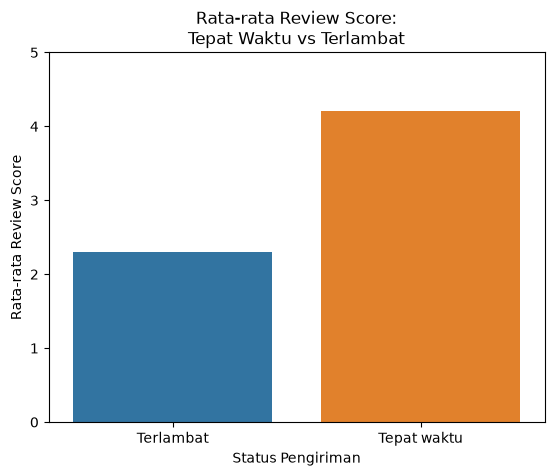

In [41]:
skor_status = q1_df.groupby('status_pengiriman')['review_score'].mean().sort_values()
sns.barplot(x=skor_status.index, y=skor_status.values, hue=skor_status.index, legend=False)
plt.title('Rata-rata Review Score:\nTepat Waktu vs Terlambat', fontsize=12)
plt.xlabel('Status Pengiriman')
plt.ylabel('Rata-rata Review Score')
plt.ylim(0, 5)

### Pertanyaan 2

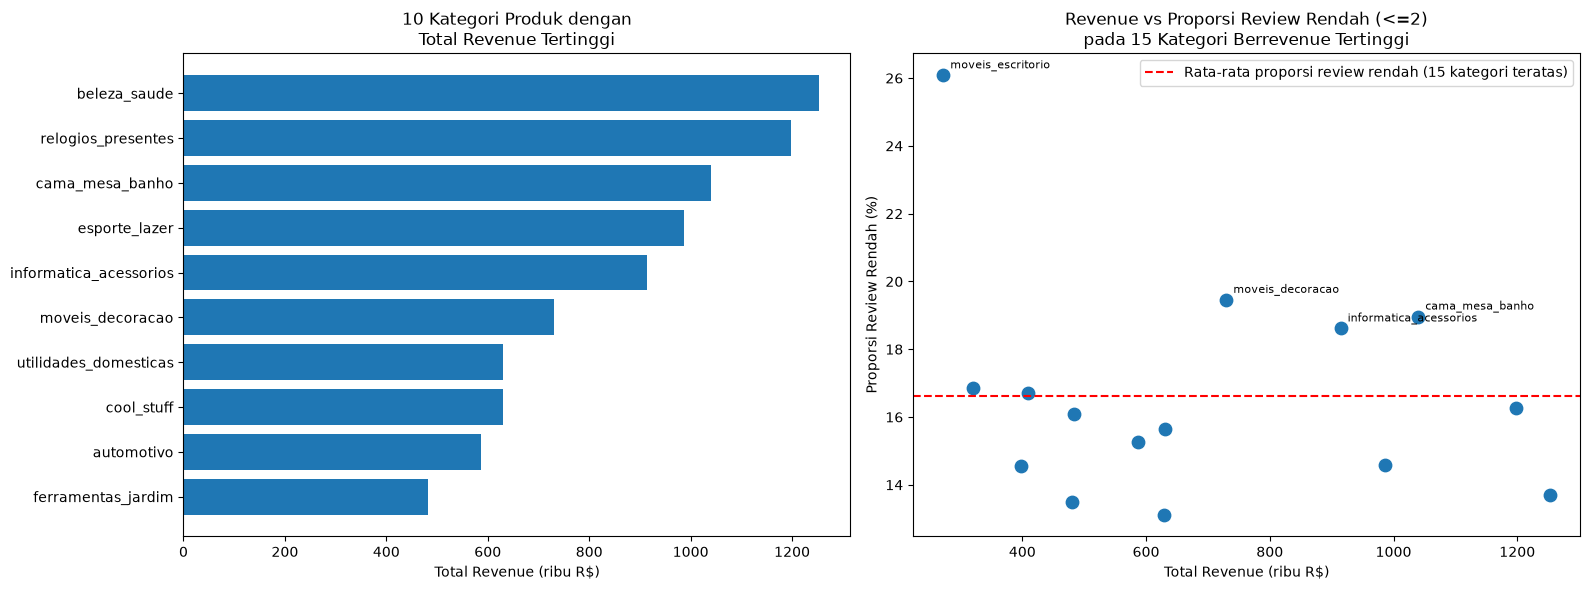

In [42]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

top10_revenue = kategori_summary.head(10).sort_values('total_revenue')
axes[0].barh(top10_revenue.index, top10_revenue['total_revenue'] / 1000)
axes[0].set_title('10 Kategori Produk dengan\nTotal Revenue Tertinggi', fontsize=12)
axes[0].set_xlabel('Total Revenue (ribu R$)')

axes[1].scatter(top15_revenue['total_revenue'] / 1000, top15_revenue['pct_review_rendah'],s=80)
for kategori, row in top15_revenue.iterrows():
    if row['pct_review_rendah'] >= 18:
        axes[1].annotate(kategori, (row['total_revenue'] / 1000, row['pct_review_rendah']),
                          fontsize=8, xytext=(5, 5), textcoords='offset points')
axes[1].axhline(top15_revenue['pct_review_rendah'].mean(), color='red', linestyle='--',
                label='Rata-rata proporsi review rendah (15 kategori teratas)')
axes[1].set_title('Revenue vs Proporsi Review Rendah (<=2)\npada 15 Kategori Berrevenue Tertinggi', fontsize=12)
axes[1].set_xlabel('Total Revenue (ribu R$)')
axes[1].set_ylabel('Proporsi Review Rendah (%)')
axes[1].legend()

plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- Grafik Pertanyaan 1 menegaskan bahwa keterlambatan pengiriman berdampak besar terhadap kepuasan pelanggan secara umum.
- Grafik Pertanyaan 2 menunjukkan bahwa 10 kategori produk dengan revenue tertinggi dan menunjukan bahwa `movies_escritorio` merupakan titik yang paling menonjol (proporsi review rendah tertinggi di antara kategori berrevenue besar), diikuti oleh `movies_decoracao`, `cama_mesa_banho`, dan `informatica_acessorios` yang berada di atas garis rata-rata

## Analisis Lanjutan (Opsional)

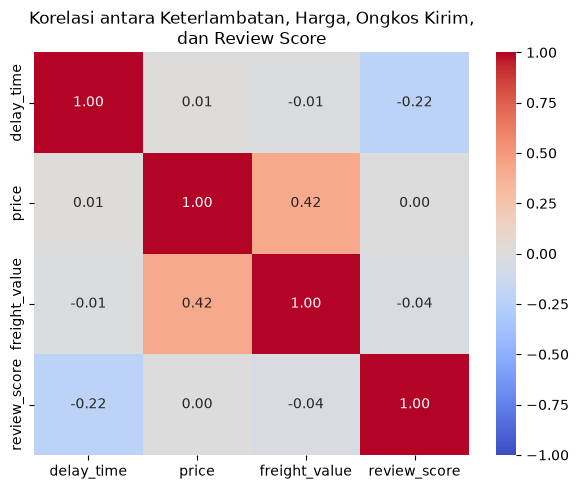

In [46]:
harga_per_order = order_item_df.groupby('order_id')[['price', 'freight_value']].mean()

corr_df = q1_df[['order_id', 'delay_time', 'review_score']].merge(
    harga_per_order, on='order_id', how='left'
)[['delay_time', 'price', 'freight_value', 'review_score']]

plt.figure(figsize=(6, 5))
sns.heatmap(corr_df.corr(), annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt=".2f")
plt.title('Korelasi antara Keterlambatan, Harga, Ongkos Kirim,\ndan Review Score')
plt.tight_layout()
plt.show()

**Insight:** (Opsional)
- `delay_time` tetap menjadi faktor dengan korelasi negatif paling kuat terhadap `review_score` dibandingkan `price` maupun `freight_value`, yang berarti kecepatan/ketepatan waktu pengiriman adalah pengungkit kepuasan pelanggan yang jauh lebih dominan dibandingkan besaran harga atau ongkos kirim

## Conclusion & Recommendation

- **Conclusion pertanyaan 1:** Keterlambatan pengiriman terbukti berpengaruh besar terhadap kepuasan pelanggan rata-rata `review_score` anjlok dari 4,2 (tepat waktu) menjadi 2,3 (terlambat), dengan korelasi negatif sebesar -0,2223. 
- **Conclusion pertanyaan 2:** Di antara 15 kategori dengan kontribusi revenue tertinggi selama 2017–2018, kategori `moveis_escritorio` memiliki kombinasi rata-rata `review_score` terendah (3,49) dan proporsi ulasan buruk (skor ≤2) tertinggi (26,1%), menandakan adanya masalah kualitas produk/layanan yang signifikan meski kategori ini tetap menghasilkan pendapatan yang besar. Kategori `movies_decoracao`, `cama_mesa_banho`, dan `informatica_acessorios` juga perlu diperhatikan karena proporsi review rendahnya di atas 18%.

**Rekomendasi Action Item:**


**Rekomendasi Action Item:**
1. Optimalisasi Logistik & Pengiriman (Menangani Temuan 1)
- Atur SLA & Penalti Kurir: Tentukan Service Level Agreement (SLA) pengiriman yang lebih ketat dan terapkan sistem penalti/evaluasi berkala bagi mitra logistik yang sering mengalami keterlambatan (delay).

2. Quality Control & Audit Kategori Rentang Bermasalah (Menangani Temuan 2)
- Audit Seller & QC Produk Kategori moveis_escritorio: Lakukan evaluasi khusus terhadap seller dan kontrol kualitas produk furnitur kantor (karena proporsi ulasan buruk mencapai 26,1%).

3. Bangun sistem pemantauan (dashboard) yang menggabungkan indikator keterlambatan pengiriman dan skor ulasan per kategori secara berkala, sehingga tim operasional dapat mendeteksi kategori bermasalah lebih awal sebelum berdampak lebih luas pada reputasi platform